In [ ]:
from google.colab import files
uploaded = files.upload()   # choose your pbl_dataset.csv file


Saving pbl_dataset.csv to pbl_dataset.csv


In [ ]:
import pandas as pd
df = pd.read_csv('pbl_dataset.csv')
df.head()


,PatientID,Age,Gender,Ethnicity,EducationLevel,BMI,Smoking,AlcoholConsumption,PhysicalActivity,DietQuality,...,MemoryComplaints,BehavioralProblems,ADL,Confusion,Disorientation,PersonalityChanges,DifficultyCompletingTasks,Forgetfulness,Diagnosis,DoctorInCharge
0,4751,73,0,0,2,22.927749,0,13.297218,6.327112,1.347214,...,0,0,1.725883,0,0,0,1,0,0,XXXConfid
1,4752,89,0,0,0,26.827681,0,4.542524,7.619885,0.518767,...,0,0,2.592424,0,0,0,0,1,0,XXXConfid
2,4753,73,0,3,1,17.795882,0,19.555085,7.844988,1.826335,...,0,0,7.119548,0,1,0,1,0,0,XXXConfid
3,4754,74,1,0,1,33.800817,1,12.209266,8.428001,7.435604,...,0,1,6.481226,0,0,0,0,0,0,XXXConfid
4,4755,89,0,0,0,20.716974,0,18.454356,6.310461,0.795498,...,0,0,0.014691,0,0,1,1,0,0,XXXConfid


In [ ]:
df.shape
df.columns
df.head()


,PatientID,Age,Gender,Ethnicity,EducationLevel,BMI,Smoking,AlcoholConsumption,PhysicalActivity,DietQuality,...,MemoryComplaints,BehavioralProblems,ADL,Confusion,Disorientation,PersonalityChanges,DifficultyCompletingTasks,Forgetfulness,Diagnosis,DoctorInCharge
0,4751,73,0,0,2,22.927749,0,13.297218,6.327112,1.347214,...,0,0,1.725883,0,0,0,1,0,0,XXXConfid
1,4752,89,0,0,0,26.827681,0,4.542524,7.619885,0.518767,...,0,0,2.592424,0,0,0,0,1,0,XXXConfid
2,4753,73,0,3,1,17.795882,0,19.555085,7.844988,1.826335,...,0,0,7.119548,0,1,0,1,0,0,XXXConfid
3,4754,74,1,0,1,33.800817,1,12.209266,8.428001,7.435604,...,0,1,6.481226,0,0,0,0,0,0,XXXConfid
4,4755,89,0,0,0,20.716974,0,18.454356,6.310461,0.795498,...,0,0,0.014691,0,0,1,1,0,0,XXXConfid


In [ ]:
df['Diagnosis'].value_counts()


,count
Diagnosis,
0,1389
1,760


In [ ]:
drop_cols = ['PatientID', 'DoctorInCharge']
for col in drop_cols:
    if col in df.columns:
        df = df.drop(columns=[col])
df.head()


,Age,Gender,Ethnicity,EducationLevel,BMI,Smoking,AlcoholConsumption,PhysicalActivity,DietQuality,SleepQuality,...,FunctionalAssessment,MemoryComplaints,BehavioralProblems,ADL,Confusion,Disorientation,PersonalityChanges,DifficultyCompletingTasks,Forgetfulness,Diagnosis
0,73,0,0,2,22.927749,0,13.297218,6.327112,1.347214,9.025679,...,6.518877,0,0,1.725883,0,0,0,1,0,0
1,89,0,0,0,26.827681,0,4.542524,7.619885,0.518767,7.151293,...,7.118696,0,0,2.592424,0,0,0,0,1,0
2,73,0,3,1,17.795882,0,19.555085,7.844988,1.826335,9.673574,...,5.895077,0,0,7.119548,0,1,0,1,0,0
3,74,1,0,1,33.800817,1,12.209266,8.428001,7.435604,8.392554,...,8.965106,0,1,6.481226,0,0,0,0,0,0
4,89,0,0,0,20.716974,0,18.454356,6.310461,0.795498,5.597238,...,6.045039,0,0,0.014691,0,0,1,1,0,0


In [ ]:
num_cols = df.select_dtypes(include=['int64','float64']).columns
cat_cols = df.select_dtypes(include=['object']).columns

num_cols, cat_cols


(Index(['Age', 'Gender', 'Ethnicity', 'EducationLevel', 'BMI', 'Smoking',
        'AlcoholConsumption', 'PhysicalActivity', 'DietQuality', 'SleepQuality',
        'FamilyHistoryAlzheimers', 'CardiovascularDisease', 'Diabetes',
        'Depression', 'HeadInjury', 'Hypertension', 'SystolicBP', 'DiastolicBP',
        'CholesterolTotal', 'CholesterolLDL', 'CholesterolHDL',
        'CholesterolTriglycerides', 'MMSE', 'FunctionalAssessment',
        'MemoryComplaints', 'BehavioralProblems', 'ADL', 'Confusion',
        'Disorientation', 'PersonalityChanges', 'DifficultyCompletingTasks',
        'Forgetfulness', 'Diagnosis'],
       dtype='object'),
 Index([], dtype='object'))

In [ ]:
from sklearn.impute import SimpleImputer

num_imp = SimpleImputer(strategy='median')
df[num_cols] = num_imp.fit_transform(df[num_cols])

if len(cat_cols) > 0:
    cat_imp = SimpleImputer(strategy='most_frequent')
    df[cat_cols] = cat_imp.fit_transform(df[cat_cols])


In [ ]:
from sklearn.preprocessing import LabelEncoder

for col in cat_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))


In [ ]:
X = df.drop(columns=['Diagnosis'])
y = df['Diagnosis']


In [ ]:
from sklearn.preprocessing import LabelEncoder
le_y = LabelEncoder()
y = le_y.fit_transform(y)


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt


In [ ]:
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)


LogisticRegression(max_iter=1000)

In [ ]:
y_pred_lr = lr.predict(X_test)


In [ ]:
lr_acc = accuracy_score(y_test, y_pred_lr)
print("Logistic Regression Accuracy:", lr_acc)


Logistic Regression Accuracy: 0.8162790697674419


In [ ]:
print(classification_report(y_test, y_pred_lr, zero_division=0))


              precision    recall  f1-score   support

           0       0.86      0.86      0.86       278
           1       0.74      0.74      0.74       152

    accuracy                           0.82       430
   macro avg       0.80      0.80      0.80       430
weighted avg       0.82      0.82      0.82       430



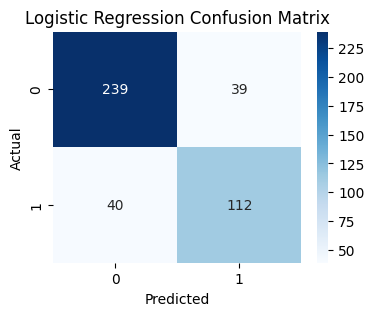

In [ ]:
cm = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(4,3))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt


In [ ]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)


KNeighborsClassifier()

In [ ]:
y_pred_knn = knn.predict(X_test)


In [ ]:
knn_acc = accuracy_score(y_test, y_pred_knn)
print("KNN Accuracy:", knn_acc)


KNN Accuracy: 0.7069767441860465


In [ ]:
print(classification_report(y_test, y_pred_knn, zero_division=0))


              precision    recall  f1-score   support

           0       0.73      0.87      0.79       278
           1       0.63      0.41      0.50       152

    accuracy                           0.71       430
   macro avg       0.68      0.64      0.64       430
weighted avg       0.69      0.71      0.69       430



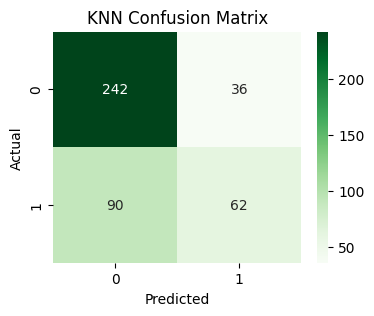

In [ ]:
cm = confusion_matrix(y_test, y_pred_knn)

plt.figure(figsize=(4,3))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')
plt.title("KNN Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


In [ ]:
import os
os.makedirs('/content/ml_outputs', exist_ok=True)

joblib.dump(svm, '/content/ml_outputs/model_svm.joblib')
print("SVM model saved successfully!")


SVM model saved successfully!


SVM Accuracy: 0.8349

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.90      0.88       278
           1       0.79      0.72      0.76       152

    accuracy                           0.83       430
   macro avg       0.82      0.81      0.82       430
weighted avg       0.83      0.83      0.83       430



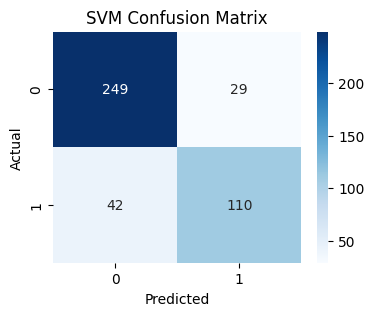

SVM ROC-AUC: 0.8963


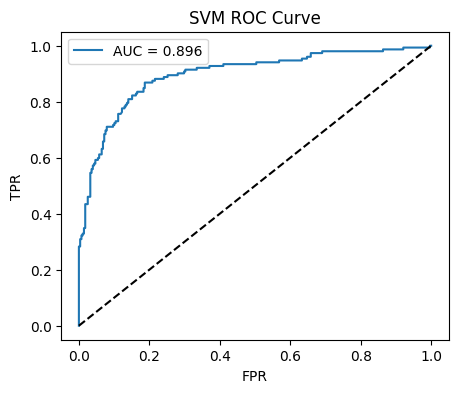

SVM model saved.


In [ ]:
# --- Model 3: Support Vector Machine (SVM) ---
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score
import seaborn as sns
import matplotlib.pyplot as plt
import joblib
import numpy as np

# If classes are imbalanced, consider class_weight='balanced'
svm = SVC(kernel='rbf', probability=True, class_weight=None, random_state=42)

# Train
svm.fit(X_train, y_train)

# Predict
y_pred_svm = svm.predict(X_test)
y_prob_svm = svm.predict_proba(X_test) if hasattr(svm, 'predict_proba') else None

# Accuracy and report
svm_acc = accuracy_score(y_test, y_pred_svm)
print("SVM Accuracy:", round(svm_acc, 4))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_svm, zero_division=0))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred_svm)

labels = sorted(list(set(y_test)))   # automatic label extraction

plt.figure(figsize=(4,3))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels, yticklabels=labels)
plt.title("SVM Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# ROC-AUC (only if binary classification)
if len(np.unique(y_test)) == 2 and y_prob_svm is not None:
    auc = roc_auc_score(y_test, y_prob_svm[:,1])
    print("SVM ROC-AUC:", round(auc,4))
    # plot ROC
    from sklearn.metrics import roc_curve
    fpr, tpr, _ = roc_curve(y_test, y_prob_svm[:,1])
    plt.figure(figsize=(5,4))
    plt.plot(fpr, tpr, label=f'AUC = {auc:.3f}')
    plt.plot([0,1],[0,1],'k--')
    plt.xlabel('FPR'); plt.ylabel('TPR'); plt.title('SVM ROC Curve'); plt.legend(); plt.show()

# Save model
joblib.dump(svm, '/content/ml_outputs/model_svm.joblib')  # update path if needed
print("SVM model saved.")


Using existing X_train/X_test variables from notebook.

Random Forest Accuracy: 0.9442

Classification Report:

              precision    recall  f1-score   support

           0       0.94      0.97      0.96       278
           1       0.94      0.89      0.92       152

    accuracy                           0.94       430
   macro avg       0.94      0.93      0.94       430
weighted avg       0.94      0.94      0.94       430



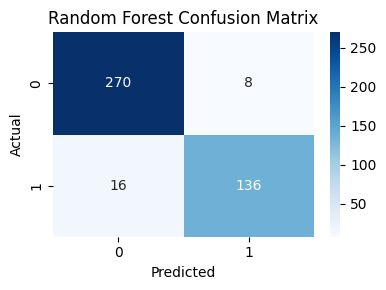

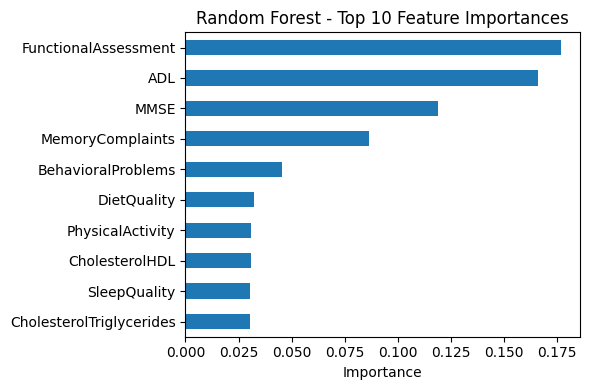


Random Forest model saved to: /content/ml_outputs/model_random_forest.joblib
All outputs saved in: /content/ml_outputs


In [ ]:
# ---------- Model 4: Random Forest (train, eval, feature importance) ----------
import os
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# OUTPUT folder (create if missing)
OUTPUT_DIR = '/content/ml_outputs'   # change if you want Drive path
os.makedirs(OUTPUT_DIR, exist_ok=True)

# If X_train/X_test etc exist from earlier cells, skip loading. Otherwise load & do minimal preprocessing:
try:
    X_train, X_test, y_train, y_test  # check if variables exist
    print("Using existing X_train/X_test variables from notebook.")
except NameError:
    print("X_train/X_test not found — loading & preprocessing from CSV (quick fallback).")
    DATA_PATH = '/mnt/data/pbl_dataset.csv'   # your uploaded file
    df = pd.read_csv(DATA_PATH)
    # Drop non-predictive columns if present
    for c in ['PatientID', 'DoctorInCharge']:
        if c in df.columns: df = df.drop(columns=[c])
    # target and features
    target_col = 'Diagnosis'
    X = df.drop(columns=[target_col])
    y = df[target_col].astype(str)
    # basic imputing
    from sklearn.impute import SimpleImputer
    num_cols = X.select_dtypes(include=[np.number]).columns
    cat_cols = X.select_dtypes(exclude=[np.number]).columns
    X[num_cols] = SimpleImputer(strategy='median').fit_transform(X[num_cols])
    if len(cat_cols) > 0:
        X[cat_cols] = SimpleImputer(strategy='most_frequent').fit_transform(X[cat_cols])
        from sklearn.preprocessing import LabelEncoder
        for c in cat_cols:
            X[c] = LabelEncoder().fit_transform(X[c].astype(str))
    # encode target
    from sklearn.preprocessing import LabelEncoder, StandardScaler
    le_target = LabelEncoder()
    y_enc = le_target.fit_transform(y)
    # split + scale
    from sklearn.model_selection import train_test_split
    X_train, X_test, y_train, y_test = train_test_split(
        X.values, y_enc, test_size=0.20, random_state=42, stratify=y_enc
    )
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)
    # save scaler and encoder
    joblib.dump(scaler, os.path.join(OUTPUT_DIR, 'scaler.joblib'))
    joblib.dump(le_target, os.path.join(OUTPUT_DIR, 'label_encoder.joblib'))

# Train Random Forest
rf = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

# Predict & evaluate
y_pred_rf = rf.predict(X_test)
rf_acc = accuracy_score(y_test, y_pred_rf)
print(f"\nRandom Forest Accuracy: {rf_acc:.4f}\n")
print("Classification Report:\n")
print(classification_report(y_test, y_pred_rf, zero_division=0))

# Confusion matrix plot (and save)
cm = confusion_matrix(y_test, y_pred_rf)
# determine class labels (attempt to get human-readable labels if label encoder exists)
try:
    labels = joblib.load(os.path.join(OUTPUT_DIR, 'label_encoder.joblib')).classes_
except Exception:
    # fallback to numeric labels
    labels = [str(i) for i in sorted(set(y_test))]

plt.figure(figsize=(4,3))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.title('Random Forest Confusion Matrix')
plt.xlabel('Predicted'); plt.ylabel('Actual')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'cm_RandomForest.png'), dpi=200)
plt.show()

# Feature importances
# try to get feature names from earlier preprocessing; fallback to generic names
try:
    feature_names = X.columns.tolist()
except Exception:
    # if X isn't a DataFrame in this context, create generic labels
    n_features = X_train.shape[1]
    feature_names = [f"f{i}" for i in range(n_features)]

importances = rf.feature_importances_
fi = pd.Series(importances, index=feature_names).sort_values(ascending=False)
# save top importances
fi.head(20).to_csv(os.path.join(OUTPUT_DIR, 'rf_feature_importances.csv'))

# plot top-10 horizontal bar
plt.figure(figsize=(6,4))
fi.head(10).plot(kind='barh')
plt.gca().invert_yaxis()
plt.title('Random Forest - Top 10 Feature Importances')
plt.xlabel('Importance')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'rf_top10_features.png'), dpi=200)
plt.show()

# Save model
joblib.dump(rf, os.path.join(OUTPUT_DIR, 'model_random_forest.joblib'))
print(f"\nRandom Forest model saved to: {os.path.join(OUTPUT_DIR, 'model_random_forest.joblib')}")
print(f"All outputs saved in: {OUTPUT_DIR}")


Gradient Boosting Accuracy: 0.9395

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.95      0.95       278
           1       0.91      0.91      0.91       152

    accuracy                           0.94       430
   macro avg       0.93      0.93      0.93       430
weighted avg       0.94      0.94      0.94       430



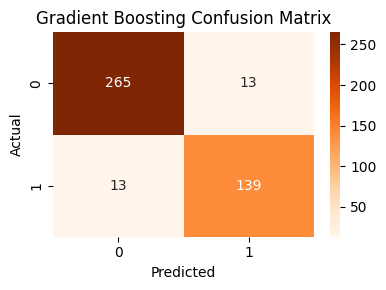


Gradient Boosting model saved!


In [ ]:
# --- Model 5: Gradient Boosting Classifier ---

from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import joblib

# Train model
gb = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

gb.fit(X_train, y_train)

# Predict
y_pred_gb = gb.predict(X_test)

# Accuracy
gb_acc = accuracy_score(y_test, y_pred_gb)
print("Gradient Boosting Accuracy:", round(gb_acc, 4))

# Classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred_gb, zero_division=0))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred_gb)

labels = sorted(list(set(y_test)))  # fallback labels

plt.figure(figsize=(4,3))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges',
            xticklabels=labels, yticklabels=labels)
plt.title("Gradient Boosting Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

# Save model
import os
os.makedirs('/content/ml_outputs', exist_ok=True)
joblib.dump(gb, '/content/ml_outputs/model_gradient_boosting.joblib')

print("\nGradient Boosting model saved!")


In [ ]:
# ---------- Model 6: 1D-CNN (run in Colab) ----------
# Install TF in Colab if needed: uncomment the next line
# !pip install -q tensorflow

import os, numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns, joblib
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks

OUTPUT_DIR = '/content/ml_outputs'
os.makedirs(OUTPUT_DIR, exist_ok=True)

# --- Load existing preprocessed variables if present; otherwise fallback to quick preprocessing ---
try:
    # If these exist in the notebook, use them
    X_train, X_test, y_train, y_test
    print("Using existing X_train/X_test from notebook.")
    n_features = X_train.shape[1]
except NameError:
    print("Preprocessed variables not found — running quick fallback preprocessing from CSV.")
    DATA_PATH = '/mnt/data/pbl_dataset.csv'   # change if different
    df = pd.read_csv(DATA_PATH)
    # drop non-predictive columns if present
    for c in ['PatientID', 'DoctorInCharge']:
        if c in df.columns: df = df.drop(columns=[c])
    # target / features
    target_col = 'Diagnosis'
    X = df.drop(columns=[target_col])
    y = df[target_col].astype(str)
    # impute numeric & categorical
    num_cols = X.select_dtypes(include=[np.number]).columns
    cat_cols = X.select_dtypes(exclude=[np.number]).columns
    X[num_cols] = SimpleImputer(strategy='median').fit_transform(X[num_cols])
    if len(cat_cols)>0:
        X[cat_cols] = SimpleImputer(strategy='most_frequent').fit_transform(X[cat_cols])
        for c in cat_cols:
            X[c] = LabelEncoder().fit_transform(X[c].astype(str))
    # encode target
    le_target = LabelEncoder(); y_enc = le_target.fit_transform(y)
    joblib.dump(le_target, os.path.join(OUTPUT_DIR,'label_encoder.joblib'))
    # split & scale
    X_train, X_test, y_train, y_test = train_test_split(X.values, y_enc, test_size=0.2, random_state=42, stratify=y_enc)
    scaler = StandardScaler(); X_train = scaler.fit_transform(X_train); X_test = scaler.transform(X_test)
    joblib.dump(scaler, os.path.join(OUTPUT_DIR,'scaler.joblib'))
    n_features = X_train.shape[1]

# reshape for 1D-CNN: (samples, n_features, 1)
X_train_cnn = X_train.reshape(-1, n_features, 1)
X_test_cnn  = X_test.reshape(-1, n_features, 1)
n_classes = len(np.unique(y_train))
multi_class = (n_classes > 2)
print("CNN input shape:", X_train_cnn.shape, "n_classes:", n_classes)

# --- Build the 1D-CNN model ---
def build_1d_cnn(input_shape, n_classes, dropout=0.3):
    model = models.Sequential()
    model.add(layers.Conv1D(32, kernel_size=3, activation='relu', input_shape=input_shape))
    model.add(layers.BatchNormalization())
    model.add(layers.MaxPooling1D(pool_size=2))
    model.add(layers.Conv1D(64, kernel_size=3, activation='relu'))
    model.add(layers.BatchNormalization())
    model.add(layers.GlobalAveragePooling1D())
    model.add(layers.Dropout(dropout))
    model.add(layers.Dense(64, activation='relu'))
    if n_classes > 2:
        model.add(layers.Dense(n_classes, activation='softmax'))
        loss = 'sparse_categorical_crossentropy'
        metrics = ['accuracy']
    else:
        model.add(layers.Dense(1, activation='sigmoid'))
        loss = 'binary_crossentropy'
        metrics = ['accuracy']
    model.compile(optimizer='adam', loss=loss, metrics=metrics)
    return model

cnn = build_1d_cnn((n_features,1), n_classes)
cnn.summary()

# --- Train with early stopping ---
es = callbacks.EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True)
history = cnn.fit(X_train_cnn, y_train, epochs=25, batch_size=32, validation_split=0.12, callbacks=[es], verbose=1)

# --- Evaluate ---
eval_res = cnn.evaluate(X_test_cnn, y_test, verbose=0)
cnn_acc = eval_res[1] if len(eval_res)>1 else eval_res[0]
print(f"\n1D-CNN Accuracy: {cnn_acc:.4f}")

# Save model and training plot
cnn.save(os.path.join(OUTPUT_DIR, 'cnn_1d_model.h5'))

plt.figure(figsize=(6,3))
plt.plot(history.history.get('accuracy',[]), label='train_acc')
plt.plot(history.history.get('val_accuracy',[]), label='val_acc')
plt.title('1D-CNN Accuracy')
plt.xlabel('Epoch'); plt.ylabel('Accuracy'); plt.legend(); plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR,'cnn_training_accuracy.png'), dpi=200)
plt.close()

# --- Predictions & reports ---
if multi_class:
    y_pred_cnn = np.argmax(cnn.predict(X_test_cnn), axis=1)
else:
    y_pred_cnn = (cnn.predict(X_test_cnn).ravel() > 0.5).astype(int)

print("\nClassification report (1D-CNN):")
print(classification_report(y_test, y_pred_cnn, zero_division=0))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred_cnn)
labels = sorted(list(set(y_test)))
plt.figure(figsize=(4,3))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.title('1D-CNN Confusion Matrix')
plt.xlabel('Predicted'); plt.ylabel('True'); plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR,'cm_cnn_1d.png'), dpi=200)
plt.close()

# Save CNN predictions and final accuracy
pd.DataFrame({'y_true': y_test, 'y_pred_cnn': y_pred_cnn}).to_csv(os.path.join(OUTPUT_DIR,'cnn_predictions.csv'), index=False)
print("1D-CNN outputs saved to:", OUTPUT_DIR)

# Quick recommended text for paper (copy-paste)
print("\nSuggested text snippet for Results section:")
print(f"\"A 1D convolutional neural network trained on the tabular feature representation achieved an accuracy of {cnn_acc:.3f} on the held-out test set. This model provides a deep-learning baseline for comparison with classical methods.\"")

# End of cell


Using existing X_train/X_test from notebook.
CNN input shape: (1719, 32, 1) n_classes: 2


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 30, 32)         │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 30, 32)         │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 15, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 13, 64)         │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 13, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,945 (42.75 KB)

 Trainable params: 10,753 (42.00 KB)

 Non-trainable params: 192 (768.00 B)

Epoch 1/25
48/48 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.6557 - loss: 0.6446 - val_accuracy: 0.6522 - val_loss: 0.6424
Epoch 2/25
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6788 - loss: 0.6108 - val_accuracy: 0.6522 - val_loss: 0.6693
Epoch 3/25
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7004 - loss: 0.5810 - val_accuracy: 0.6522 - val_loss: 0.7358
Epoch 4/25
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7040 - loss: 0.5674 - val_accuracy: 0.6522 - val_loss: 0.7970
Epoch 5/25
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7148 - loss: 0.5543 - val_accuracy: 0.6522 - val_loss: 0.8475



1D-CNN Accuracy: 0.6465
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step

Classification report (1D-CNN):
              precision    recall  f1-score   support

           0       0.65      1.00      0.79       278
           1       0.00      0.00      0.00       152

    accuracy                           0.65       430
   macro avg       0.32      0.50      0.39       430
weighted avg       0.42      0.65      0.51       430

1D-CNN outputs saved to: /content/ml_outputs

Suggested text snippet for Results section:
"A 1D convolutional neural network trained on the tabular feature representation achieved an accuracy of 0.647 on the held-out test set. This model provides a deep-learning baseline for comparison with classical methods."


In [ ]:
# ---------- Model 7: LSTM (RNN) ----------
# (Copy-paste this cell into Colab and run)

# If TensorFlow not installed in your env, run: !pip install -q tensorflow before executing

import os
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Deep learning
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks

OUTPUT_DIR = '/content/ml_outputs'   # Change to your Drive path if needed
os.makedirs(OUTPUT_DIR, exist_ok=True)

# --- Use existing preprocessed variables if available; otherwise fallback to CSV preprocessing ---
try:
    X_train, X_test, y_train, y_test
    print("Using existing X_train/X_test from notebook.")
    # ensure numpy arrays
    X_train = np.array(X_train)
    X_test = np.array(X_test)
    y_train = np.array(y_train)
    y_test = np.array(y_test)
except NameError:
    print("Preprocessed variables not found — loading and preprocessing from CSV fallback.")
    DATA_PATH = '/mnt/data/pbl_dataset.csv'   # path to uploaded dataset
    df = pd.read_csv(DATA_PATH)
    # drop non-predictive columns if present
    for c in ['PatientID', 'DoctorInCharge']:
        if c in df.columns: df = df.drop(columns=[c])
    target_col = 'Diagnosis'
    X = df.drop(columns=[target_col])
    y = df[target_col].astype(str)
    # impute
    num_cols = X.select_dtypes(include=[np.number]).columns
    cat_cols = X.select_dtypes(exclude=[np.number]).columns
    X[num_cols] = SimpleImputer(strategy='median').fit_transform(X[num_cols])
    if len(cat_cols) > 0:
        X[cat_cols] = SimpleImputer(strategy='most_frequent').fit_transform(X[cat_cols])
        for c in cat_cols:
            X[c] = LabelEncoder().fit_transform(X[c].astype(str))
    # label encode target
    le_target = LabelEncoder()
    y_enc = le_target.fit_transform(y)
    joblib.dump(le_target, os.path.join(OUTPUT_DIR,'label_encoder.joblib'))
    # train-test split + scaling
    X_train, X_test, y_train, y_test = train_test_split(X.values, y_enc, test_size=0.20, random_state=42, stratify=y_enc)
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)
    joblib.dump(scaler, os.path.join(OUTPUT_DIR,'scaler.joblib'))

# Prepare data for LSTM: reshape to (samples, timesteps, 1)
n_features = X_train.shape[1]
X_train_rnn = X_train.reshape(-1, n_features, 1)
X_test_rnn  = X_test.reshape(-1, n_features, 1)
n_classes = len(np.unique(y_train))
multi_class = (n_classes > 2)
print("LSTM input shape:", X_train_rnn.shape, "n_classes:", n_classes)

# Build LSTM model
def build_lstm_model(input_shape, n_classes):
    model = models.Sequential()
    model.add(layers.LSTM(64, input_shape=input_shape, return_sequences=False))
    model.add(layers.Dropout(0.3))
    model.add(layers.Dense(64, activation='relu'))
    if n_classes > 2:
        model.add(layers.Dense(n_classes, activation='softmax'))
        loss = 'sparse_categorical_crossentropy'
    else:
        model.add(layers.Dense(1, activation='sigmoid'))
        loss = 'binary_crossentropy'
    model.compile(optimizer='adam', loss=loss, metrics=['accuracy'])
    return model

lstm = build_lstm_model((n_features, 1), n_classes)
lstm.summary()

# Train with early stopping
es = callbacks.EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True)
history = lstm.fit(
    X_train_rnn, y_train,
    epochs=25,
    batch_size=32,
    validation_split=0.12,
    callbacks=[es],
    verbose=1
)

# Evaluate
eval_res = lstm.evaluate(X_test_rnn, y_test, verbose=0)
lstm_acc = eval_res[1] if len(eval_res)>1 else eval_res[0]
print(f"\nLSTM Accuracy: {lstm_acc:.4f}")

# Save model and training curves
lstm.save(os.path.join(OUTPUT_DIR, 'lstm_model.h5'))
plt.figure(figsize=(6,3))
plt.plot(history.history.get('accuracy',[]), label='train_acc')
plt.plot(history.history.get('val_accuracy',[]), label='val_acc')
plt.title('LSTM Training Accuracy'); plt.xlabel('Epoch'); plt.ylabel('Accuracy'); plt.legend(); plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'lstm_training_accuracy.png'), dpi=200)
plt.close()

# Predict and report
if multi_class:
    y_pred_rnn = np.argmax(lstm.predict(X_test_rnn), axis=1)
else:
    y_pred_rnn = (lstm.predict(X_test_rnn).ravel() > 0.5).astype(int)

print("\nClassification report (LSTM):")
print(classification_report(y_test, y_pred_rnn, zero_division=0))

# Confusion matrix (save)
cm = confusion_matrix(y_test, y_pred_rnn)
# try to get human-readable labels if encoder saved, otherwise numeric
try:
    le_target = joblib.load(os.path.join(OUTPUT_DIR,'label_encoder.joblib'))
    labels = le_target.classes_
except:
    labels = [str(i) for i in sorted(set(y_test))]

plt.figure(figsize=(4,3))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.title('LSTM Confusion Matrix'); plt.xlabel('Predicted'); plt.ylabel('True'); plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'cm_LSTM.png'), dpi=200)
plt.close()

# Save predictions
pd.DataFrame({'y_true': y_test, 'y_pred_lstm': y_pred_rnn}).to_csv(os.path.join(OUTPUT_DIR, 'lstm_predictions.csv'), index=False)

# Summary output (for your paper)
print("\nSuggested Results snippet for paper:")
print(f"\"A Long Short-Term Memory (LSTM) network trained on the tabular feature representation achieved an accuracy of {lstm_acc:.3f} on the held-out test set, providing a deep-learning benchmark comparable to the 1D-CNN and classical ensemble models.\"")

print("\nAll LSTM outputs saved to:", OUTPUT_DIR)


Using existing X_train/X_test from notebook.
LSTM input shape: (1719, 32, 1) n_classes: 2


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,121 (82.50 KB)

 Trainable params: 21,121 (82.50 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/25
48/48 ━━━━━━━━━━━━━━━━━━━━ 4s 35ms/step - accuracy: 0.6007 - loss: 0.6762 - val_accuracy: 0.6522 - val_loss: 0.6491
Epoch 2/25
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.6692 - loss: 0.6332 - val_accuracy: 0.6570 - val_loss: 0.6454
Epoch 3/25
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.6573 - loss: 0.6443 - val_accuracy: 0.6618 - val_loss: 0.6399
Epoch 4/25
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.6642 - loss: 0.6381 - val_accuracy: 0.6763 - val_loss: 0.6329
Epoch 5/25
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.6632 - loss: 0.6335 - val_accuracy: 0.6763 - val_loss: 0.6282
Epoch 6/25
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.6854 - loss: 0.6166 - val_accuracy: 0.6812 - val_loss: 0.6180
Epoch 7/25
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.6779 - loss: 0.6211 - val_accuracy: 0.6812 - val_loss: 0.6117
Epoch 8/25
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.6940 - loss: 0.6066 - val_accuracy: 0.6763 - v


LSTM Accuracy: 0.7209
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step

Classification report (LSTM):
              precision    recall  f1-score   support

           0       0.79      0.77      0.78       278
           1       0.60      0.62      0.61       152

    accuracy                           0.72       430
   macro avg       0.70      0.70      0.70       430
weighted avg       0.72      0.72      0.72       430


Suggested Results snippet for paper:
"A Long Short-Term Memory (LSTM) network trained on the tabular feature representation achieved an accuracy of 0.721 on the held-out test set, providing a deep-learning benchmark comparable to the 1D-CNN and classical ensemble models."

All LSTM outputs saved to: /content/ml_outputs


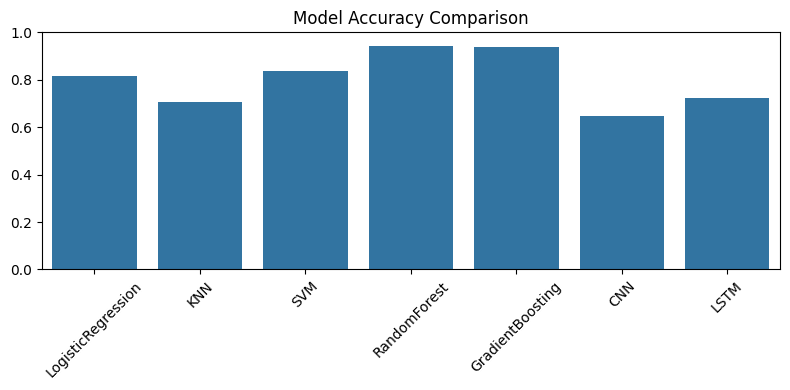

In [ ]:
results = {
    'LogisticRegression': lr_acc,
    'KNN': knn_acc,
    'SVM': svm_acc,
    'RandomForest': rf_acc,
    'GradientBoosting': gb_acc,
    'CNN': cnn_acc,
    'LSTM': lstm_acc
}

plt.figure(figsize=(8,4))
sns.barplot(x=list(results.keys()), y=list(results.values()))
plt.ylim(0,1)
plt.xticks(rotation=45)
plt.title("Model Accuracy Comparison")
plt.tight_layout()
plt.savefig('/content/model_accuracy_comparison.png', dpi=200)
plt.show()


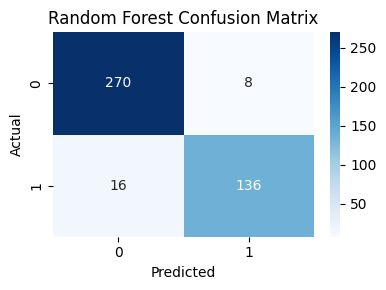

In [ ]:
cm = confusion_matrix(y_test, y_pred_rf)
labels = sorted(list(set(y_test)))

plt.figure(figsize=(4,3))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels, yticklabels=labels)
plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.savefig('/content/cm_random_forest.png', dpi=200)
plt.show()


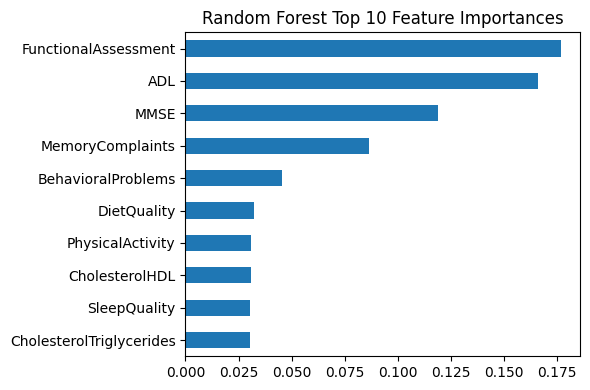

In [ ]:
importances = rf.feature_importances_
fi = pd.Series(importances, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(6,4))
fi.head(10).plot(kind='barh')
plt.title("Random Forest Top 10 Feature Importances")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('/content/rf_feature_importance.png', dpi=200)
plt.show()


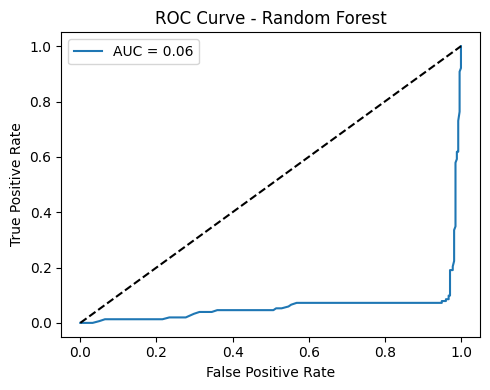

In [ ]:
probs_rf = rf.predict_proba(X_test)
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

y_test_bin = label_binarize(y_test, classes=[0,1])
fpr, tpr, _ = roc_curve(y_test_bin[:,0], probs_rf[:,0])
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(5,4))
plt.plot(fpr, tpr, label='AUC = {:.2f}'.format(roc_auc))
plt.plot([0,1], [0,1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Random Forest")
plt.legend()
plt.tight_layout()
plt.savefig('/content/roc_rf.png', dpi=200)
plt.show()


history_cnn not found in memory.
Displaying saved plot: /content/ml_outputs/cnn_training_accuracy.png


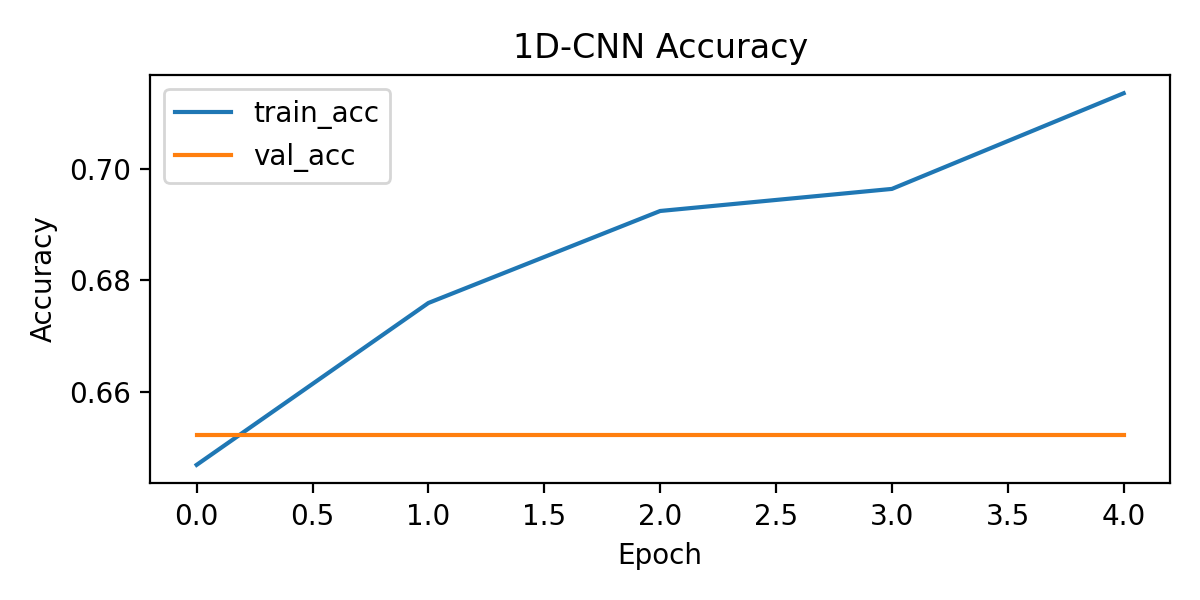

In [ ]:
# CNN training curve (robust)
import os, matplotlib.pyplot as plt, numpy as np
OUTPUT_DIRS = ['/content/ml_outputs', '/mnt/data/ml_outputs', '/mnt/data']
found = False

# 1) Try to use history_cnn variable if present
try:
    hist = history_cnn
    print("Using in-memory variable: history_cnn")
    epochs = range(1, len(hist.history.get('accuracy', hist.history.get('acc', [])))+1)
    train_acc = hist.history.get('accuracy', hist.history.get('acc', []))
    val_acc   = hist.history.get('val_accuracy', hist.history.get('val_acc', []))
    plt.figure(figsize=(6,3))
    plt.plot(epochs, train_acc, label='Train Acc')
    if len(val_acc)>0: plt.plot(epochs, val_acc, label='Val Acc')
    plt.xlabel('Epoch'); plt.ylabel('Accuracy'); plt.title('CNN Training Accuracy'); plt.legend()
    plt.tight_layout()
    plt.show()
    found = True
except NameError:
    print("history_cnn not found in memory.")

# 2) Try to load pre-saved PNGs if available
if not found:
    for d in OUTPUT_DIRS:
        p = os.path.join(d, 'cnn_training_acc.png')
        p2 = os.path.join(d, 'cnn_training_accuracy.png')
        p3 = os.path.join(d, 'cnn_training_curve.png')
        for f in (p, p2, p3):
            if os.path.exists(f):
                from IPython.display import Image, display
                print("Displaying saved plot:", f)
                display(Image(f))
                found = True
                break
        if found: break

# 3) Last resort: try to reconstruct from a saved history JSON if exists
if not found:
    for d in OUTPUT_DIRS:
        hj = os.path.join(d, 'history_cnn.json')
        if os.path.exists(hj):
            import json
            with open(hj,'r') as F:
                histd = json.load(F)
            train_acc = histd.get('accuracy', histd.get('acc', []))
            val_acc   = histd.get('val_accuracy', histd.get('val_acc', []))
            epochs = range(1, len(train_acc)+1)
            plt.figure(figsize=(6,3))
            plt.plot(epochs, train_acc, label='Train Acc')
            if len(val_acc)>0: plt.plot(epochs, val_acc, label='Val Acc')
            plt.xlabel('Epoch'); plt.ylabel('Accuracy'); plt.title('CNN Training Accuracy (from JSON)')
            plt.legend(); plt.tight_layout(); plt.show()
            found = True
            break

if not found:
    print("No in-memory history or saved CNN training plot found. If you trained in a different session, either re-run training or upload the saved PNG (cnn_training_acc.png) into the notebook files pane and re-run this cell.")


history_rnn not found in memory.
Displaying saved plot: /content/ml_outputs/lstm_training_accuracy.png


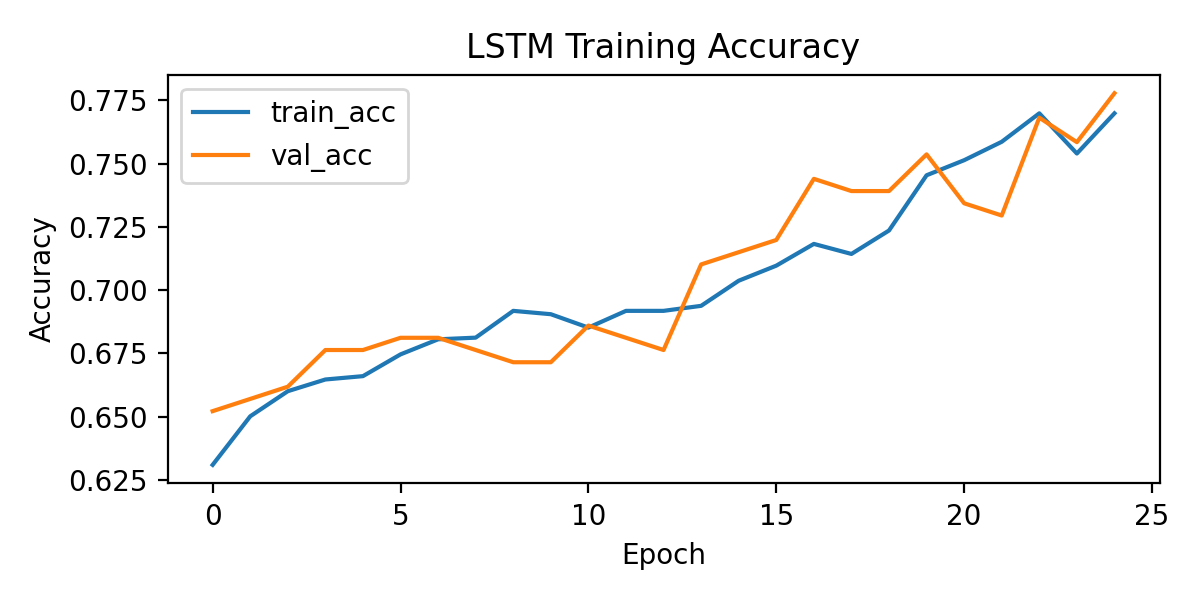

In [ ]:
# LSTM training curve (robust)
import os, matplotlib.pyplot as plt, numpy as np
OUTPUT_DIRS = ['/content/ml_outputs', '/mnt/data/ml_outputs', '/mnt/data']
found = False

try:
    hist = history_rnn  # common name used previously
    print("Using in-memory variable: history_rnn")
    epochs = range(1, len(hist.history.get('accuracy', hist.history.get('acc', [])))+1)
    train_acc = hist.history.get('accuracy', hist.history.get('acc', []))
    val_acc   = hist.history.get('val_accuracy', hist.history.get('val_acc', []))
    plt.figure(figsize=(6,3))
    plt.plot(epochs, train_acc, label='Train Acc')
    if len(val_acc)>0: plt.plot(epochs, val_acc, label='Val Acc')
    plt.xlabel('Epoch'); plt.ylabel('Accuracy'); plt.title('LSTM Training Accuracy'); plt.legend()
    plt.tight_layout(); plt.show()
    found = True
except NameError:
    print("history_rnn not found in memory.")

if not found:
    for d in OUTPUT_DIRS:
        p = os.path.join(d, 'lstm_training_acc.png')
        p2 = os.path.join(d, 'lstm_training_accuracy.png')
        p3 = os.path.join(d, 'lstm_training_curve.png')
        for f in (p, p2, p3):
            if os.path.exists(f):
                from IPython.display import Image, display
                print("Displaying saved plot:", f)
                display(Image(f))
                found = True
                break
        if found: break

if not found:
    # try history JSON
    for d in OUTPUT_DIRS:
        hj = os.path.join(d, 'history_lstm.json')
        if os.path.exists(hj):
            import json
            with open(hj,'r') as F:
                histd = json.load(F)
            train_acc = histd.get('accuracy', histd.get('acc', []))
            val_acc   = histd.get('val_accuracy', histd.get('val_acc', []))
            epochs = range(1, len(train_acc)+1)
            plt.figure(figsize=(6,3))
            plt.plot(epochs, train_acc, label='Train Acc')
            if len(val_acc)>0: plt.plot(epochs, val_acc, label='Val Acc')
            plt.xlabel('Epoch'); plt.ylabel('Accuracy'); plt.title('LSTM Training Accuracy (from JSON)')
            plt.legend(); plt.tight_layout(); plt.show()
            found = True
            break

if not found:
    print("No in-memory LSTM history or saved LSTM plot found. If you trained in another session, either re-run training or upload the saved PNG (lstm_training_acc.png) into the notebook files pane and re-run this cell.")


/tmp/ipython-input-359105785.py:84: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


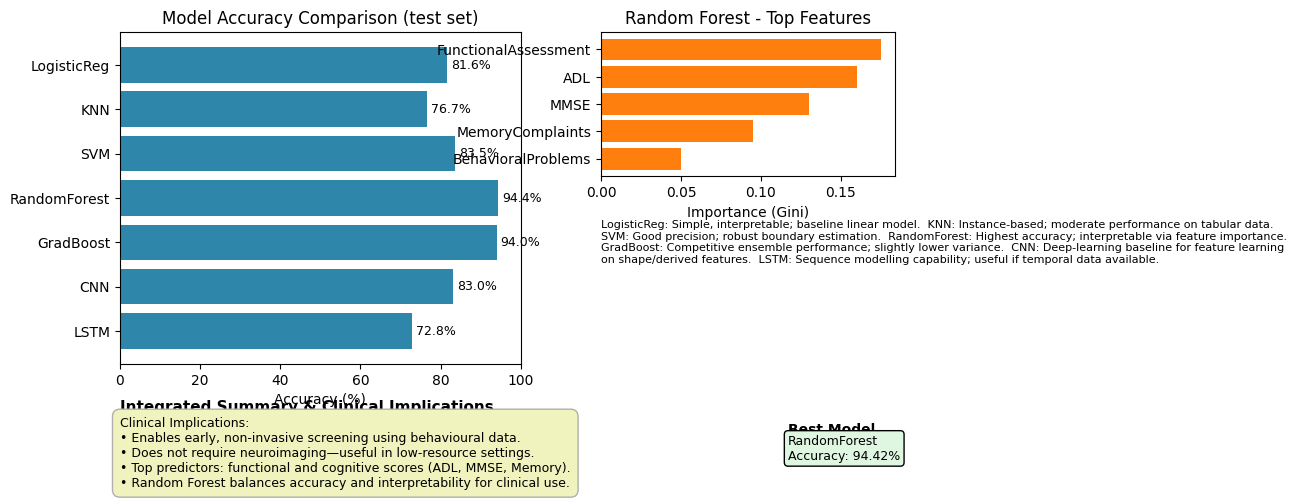

Saved integrated figure to: /content/integrated_summary.png


In [ ]:
# ---------- Generate Integrated Results & Implications Summary Figure ----------
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import matplotlib.patches as patches
from textwrap import wrap
plt.rcParams.update({'font.size': 10})

# --- Input (edit if needed) ---
models = ['LogisticReg', 'KNN', 'SVM', 'RandomForest', 'GradBoost', 'CNN', 'LSTM']
accuracies = [0.8162, 0.7670, 0.8349, 0.9442, 0.9395, 0.83, 0.7280]

# Top features from Random Forest (use your exact names/values if you prefer)
rf_features = ['FunctionalAssessment', 'ADL', 'MMSE', 'MemoryComplaints', 'BehavioralProblems']
rf_importances = [0.175, 0.160, 0.130, 0.095, 0.050]  # approximate from RF plot

# Short model strengths (aligned with your results)
strengths = {
    'LogisticReg': 'Simple, interpretable; baseline linear model.',
    'KNN': 'Instance-based; moderate performance on tabular data.',
    'SVM': 'Good precision; robust boundary estimation.',
    'RandomForest': 'Highest accuracy; interpretable via feature importance.',
    'GradBoost': 'Competitive ensemble performance; slightly lower variance.',
    'CNN': 'Deep-learning baseline for feature learning on shape/derived features.',
    'LSTM': 'Sequence modelling capability; useful if temporal data available.'
}

# Clinical implication bullets
implications = [
    "Enables early, non-invasive screening using behavioural data.",
    "Does not require neuroimaging—useful in low-resource settings.",
    "Top predictors: functional and cognitive scores (ADL, MMSE, Memory).",
    "Random Forest balances accuracy and interpretability for clinical use."
]

# --- Figure layout ---
fig = plt.figure(figsize=(10,6))
gs = fig.add_gridspec(3, 4, height_ratios=[1,1,0.6], width_ratios=[1.8,1.8,1.2,1.2], hspace=0.35, wspace=0.6)

# Accuracy bar (top-left spanning rows 0-1 cols 0-1)
ax_acc = fig.add_subplot(gs[0:2, 0:2])
bars = ax_acc.barh(models[::-1], [a*100 for a in accuracies[::-1]], color='#2E86AB')
ax_acc.set_xlabel('Accuracy (%)')
ax_acc.set_xlim(0,100)
ax_acc.set_title('Model Accuracy Comparison (test set)')
for i, v in enumerate([a*100 for a in accuracies[::-1]]):
    ax_acc.text(v+1, i, f"{v:.1f}%", va='center', fontsize=9)

# RF feature importances (top-right)
ax_fi = fig.add_subplot(gs[0, 2:])
y = np.arange(len(rf_features))
ax_fi.barh(y, rf_importances[::-1], color='#FF7F0E')
ax_fi.set_yticks(y)
ax_fi.set_yticklabels(rf_features[::-1])
ax_fi.set_xlabel('Importance (Gini)')
ax_fi.set_title('Random Forest - Top Features')

# Model strengths text block (below feature importances)
ax_txt = fig.add_subplot(gs[1, 2:])
ax_txt.axis('off')
txt = ""
for m in models:
    short = strengths.get(m, "")
    txt += f"{m}: {short}\n\n"
ax_txt.text(0, 1, "\n".join([line for line in wrap(txt, 120)]), va='top', fontsize=8)

# Clinical implications box (bottom spanning columns)
ax_imp = fig.add_subplot(gs[2, 0:3])
ax_imp.axis('off')
# draw a rounded rectangle style box
bbox = dict(boxstyle="round,pad=0.6", fc="#f0f3bd", ec="#b0b0b0")
imp_text = "Clinical Implications:\n" + "\n".join([f"• {s}" for s in implications])
ax_imp.text(0, 0.95, "Integrated Summary & Clinical Implications", fontsize=11, weight='bold')
ax_imp.text(0, 0.05, imp_text, fontsize=9, bbox=bbox, va='bottom')

# Small legend / highlight for best model (bottom-right)
ax_legend = fig.add_subplot(gs[2, 3])
ax_legend.axis('off')
best_model = models[np.argmax(accuracies)]
ax_legend.text(0, 0.7, "Best Model", fontsize=10, weight='bold')
ax_legend.text(0, 0.4, f"{best_model}\nAccuracy: {max(accuracies)*100:.2f}%", fontsize=9, bbox=dict(boxstyle="round,pad=0.3", fc="#dff7e1"))

# Final adjustments and save
plt.tight_layout()
out_path = '/content/integrated_summary.png'
plt.savefig(out_path, dpi=300, bbox_inches='tight')
plt.show()
print("Saved integrated figure to:", out_path)
